# Calculate Soil Volumetric Water Content using ABoVE UAVSAR Data

In this tutorial, we will read the [Active Layer Thickness from Airborne L- and P- band SAR dataset](https://doi.org/10.3334/ORNLDAAC/2004) using direct access method from NASA Earthdata Cloud, and calculate soil volumetric water content using the UAVSAR data.

This dataset provides active layer thickness (ALT) and the vertical soil moisture profile retrievals imultaneously use L- and P-band synthetic aperture radar (SAR) data acquired by the NASA/JPL Uninhabited Aerial Vehicle Synthetic Aperture Radar ([UAVSAR](https://www.earthdata.nasa.gov/data/instruments/uavsar)) instruments  across the [ABoVE domain](https://www.earthdata.nasa.gov/data/projects/above). The data are provided in NetCDF Version 4 format.

In [1]:
import earthaccess
import s3fs
import xarray as xr
import numpy as np
import warnings
import matplotlib.pyplot as plt
# suppress future warnings
warnings.filterwarnings('ignore', category=FutureWarning)

## Authentication
We recommend authenticating your Earthdata Login (EDL) information using the `earthaccess` python library as follows:

In [2]:
# works if the EDL login already been persisted to a netrc
try:
    auth = earthaccess.login(strategy="netrc")
except FileNotFoundError:
    # ask for EDL credentials and persist them in a .netrc file
    auth = earthaccess.login(strategy="interactive", persist=True)

## Search granules
We will using the `earthaccess` module to search the granules within the UAVSAR dataset. W

In [3]:
doi = '10.3334/ORNLDAAC/2004' # uavsar data
granules = earthaccess.search_data(
    granule_name = f"*.nc4", # retrieve only netcdfs
    cloud_hosted=True, # make sure dataset is in cloud for direct access
    doi=doi
)
print(f'Granules found: {len(granules)}')

Granules found: 51


## Directly access a granule
Let's use `earthaccess.open` to open the first granule as S3FileSystem object, which mimics the standard Python file protocol, allowing you to read and write data to S3 object.

In [4]:
s3fs = earthaccess.open(granules[:1])
s3fs

QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

[<File-like object S3FileSystem, ornl-cumulus-prod-protected/above/ABoVE_ReSALT_InSAR_PolSAR_V3/data/PDO_ReSALT_scoaoi_2017_03.nc4>]

Let's open the above S3FileSystem object using `xarray` module.

In [5]:
ds = xr.open_dataset(s3fs[0], engine='h5netcdf', chunks={})
ds

<xarray.Dataset> Size: 569MB
Dimensions:  (y: 2959, x: 2827)
Coordinates:
  * x        (x) float64 23kB -1.358e+06 -1.358e+06 ... -1.273e+06 -1.273e+06
  * y        (y) float64 24kB 2.556e+06 2.556e+06 ... 2.467e+06 2.467e+06
    lat      (y, x) float64 67MB dask.array<chunksize=(1480, 1414), meta=np.ndarray>
    lon      (y, x) float64 67MB dask.array<chunksize=(1480, 1414), meta=np.ndarray>
Data variables: (12/14)
    crs      |S1 1B ...
    alt      (y, x) float32 33MB dask.array<chunksize=(1480, 1414), meta=np.ndarray>
    alt_unc  (y, x) float32 33MB dask.array<chunksize=(1480, 1414), meta=np.ndarray>
    sub      (y, x) float32 33MB dask.array<chunksize=(1480, 1414), meta=np.ndarray>
    sub_unc  (y, x) float32 33MB dask.array<chunksize=(1480, 1414), meta=np.ndarray>
    Sw0      (y, x) float32 33MB dask.array<chunksize=(1480, 1414), meta=np.ndarray>
    ...       ...
    wtd_unc  (y, x) float32 33MB dask.array<chunksize=(1480, 1414), meta=np.ndarray>
    mv_6cm   (y, x) float32 33MB dask.array<chunksize=(1480, 1414), meta=np.ndarray>
    mv_12cm  (y, x) float32 33MB dask.array<chunksize=(1480, 1414), meta=np.ndarray>
    mv_20cm  (y, x) float32 33MB dask.array<chunksize=(1480, 1414), meta=np.ndarray>
    mv_alt   (y, x) float32 33MB dask.array<chunksize=(1480, 1414), meta=np.ndarray>
    qa       (y, x) float32 33MB dask.array<chunksize=(2959, 2827), meta=np.ndarray>
Attributes:
    title:            Active Layer Thickness Derived from Airborne L- and P-b...
    source:           The Airborne InSAR and PolSAR Permafrost Dynamics Obser...
    project:          Arctic-Boreal Vulnerability Experiment (ABoVE)
    Conventions:      CF-1.6
    summary:          This data file provides estimates of seasonal subsidenc...
    references:       Chen et al. 2018 https://doi.org/10.1109/IGARSS.2018.85...
    publisher_name:   Oak Ridge National Laboratory (ORNL) Distributed Active...
    publisher_url:    https://daac.ornl.gov
    publisher_email:  uso@daac.ornl.gov
    citation:         Chen, R.H., R.J. Michaelides, J. Chen, A.C. Chen, L.K. ...

## Plots of selected variables
Let's plot three key variables we will use later to compute soil volumetric moisture content.

### Soil water saturation fraction at the surface (z=0)

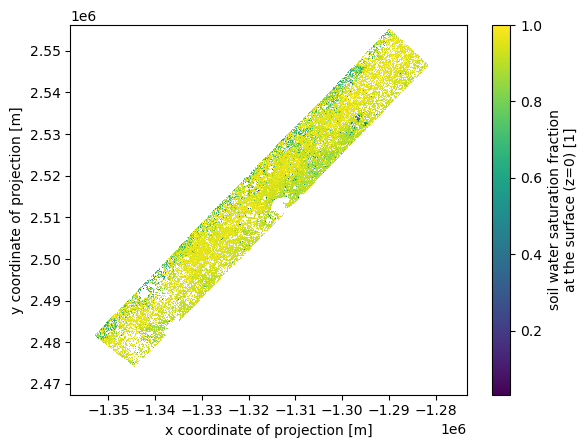

In [6]:
ds.Sw0.plot()
plt.show()

### Water table depth

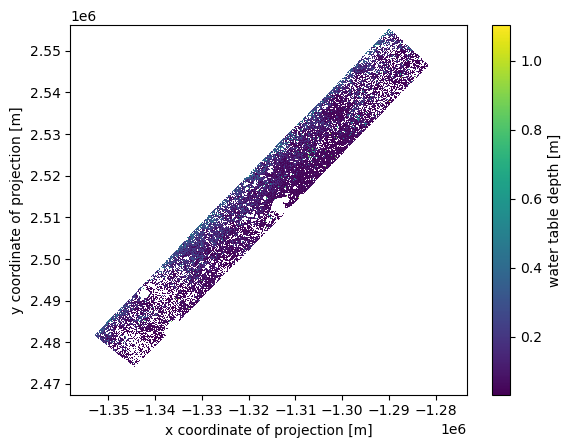

In [7]:
ds.wtd.plot()
plt.show()

### Active layer thickness

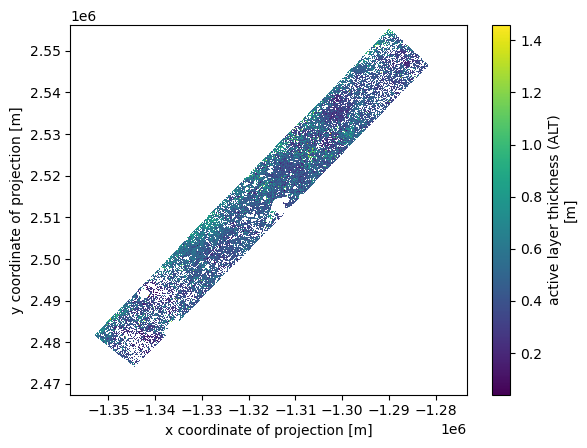

In [8]:
ds.alt.plot()
plt.show()

## Calculate soil volumetric water content (VWC)
Now, that we have opened a single granule above, we can compute the soil volumetric water content (VWC). The calculation will be based on [this code](https://data.ornldaac.earthdata.nasa.gov/protected/above/ABoVE_ReSALT_InSAR_PolSAR_V3/data/generate_pdo_soil_vwc.py) provided with the dataset. For this tutorial, let's compute the volumetric water content (VWC) at 0.3m soil depth.

In [9]:
# soil depth in meters
davg = 0.3

Let's instantiate porosity profile at various soil depths assuming a 15-cm surface organic layer.

In [10]:
# soil depths upto 1.5m at 0.01m interval
depth = np.arange(0, 1.51, 0.01)
# porosity profile 
poros = np.zeros(depth.shape)
poros[0:60] = [0.898544856, 0.898499062, 0.898423619, 0.898299395,
               0.898095018, 0.897759235, 0.897208803, 0.896309857,
               0.894850646, 0.892505296, 0.888794675, 0.883063585,
               0.874497473, 0.862106338, 0.844293206, 0.817876684,
               0.779170531, 0.729407351, 0.676689093, 0.629853558,
               0.593348919, 0.567343140, 0.549886512, 0.538609107,
               0.531497790, 0.527080555, 0.524362119, 0.522698640,
               0.521684243, 0.521066965, 0.520691823, 0.520464014,
               0.520325740, 0.520241835, 0.520190930, 0.520160050,
               0.520141318, 0.520129956, 0.520123065, 0.520118885,
               0.520116349, 0.520114812, 0.520113879, 0.520113313,
               0.520112970, 0.520112762, 0.520112636, 0.520112559,
               0.520112513, 0.520112484, 0.520112467, 0.520112457,
               0.520112451, 0.520112447, 0.520112445, 0.520112443,
               0.520112442, 0.520112442, 0.520112441, 0.520112441]
poros[60:] = 0.520112441

Now, compute soil volumetric water content averaged to depth `davg` (0.3m) and plot.

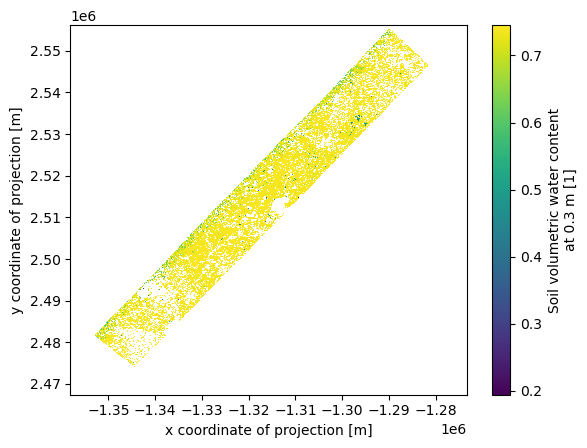

In [11]:
alt = ds.alt.values
Sw0 = ds.Sw0.values
wtd = ds.wtd.values
# masking the pixels where wtd is not retrieved and where alt < 0.3 soil depth
mv_avg = np.where((np.isnan(wtd) | (alt < davg)), np.nan, 0)

# calculate vwc averaged to dvag
for idx, z in enumerate(depth):
    if z < davg:
        Sw = np.where(wtd > z, ((Sw0 - 1) / wtd**2) * (z - wtd)**2 + 1, 1)
        mv = Sw * poros[idx]
        mv_avg = mv_avg + mv * 0.01
    else:
        break
mv_avg = mv_avg / davg

# create vwc as a new variable in dataset
ds = ds.assign(mv_avg = ds.Sw0)
ds.mv_avg[:] = np.nan
ds.mv_avg[:] = mv_avg
ds.mv_avg.attrs['long_name'] = f'Soil volumetric water content at {davg} m'

# plot
ds.mv_avg.plot()
plt.show()